--- SINGLE LINEAR REGRESSION METRICS ---
Feature Used:             Pclass
Slope Coefficient (β1):   -17.6052
Intercept (β0):           64.9194
Mean Absolute Error (MAE): 10.6422
Root Mean Squared Error:   13.5915
R-squared (R² Score):        0.5539

Mathematical Formula: Fare = 64.92 + (-17.61 * Pclass)


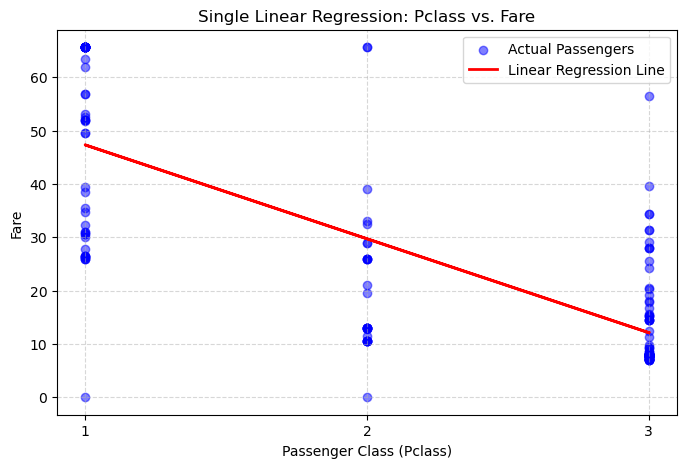

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================================
# STEP 1: Load Cleaned Dataset & Select 1 Feature
# =====================================================================
df = pd.read_csv('cleaned_titanic_dataset.csv')

# Determine target column
target_col = 'Fare' if 'Fare' in df.columns else 'Fare_scaled'

# Select ONLY 1 feature (Pclass) and 1 target (Fare)
# Note: X must be a 2D DataFrame [[ 'Pclass' ]], not a 1D Series
X = df[['Pclass']]
y = df[target_col]

# =====================================================================
# STEP 2: Train-Test Split (80/20)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# STEP 3: Train Single Linear Regression Model
# =====================================================================
model = LinearRegression()
model.fit(X_train, y_train)

# =====================================================================
# STEP 4: Make Predictions & Evaluate
# =====================================================================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- SINGLE LINEAR REGRESSION METRICS ---")
print(f"Feature Used:             Pclass")
print(f"Slope Coefficient (β1):   {model.coef_[0]:.4f}")
print(f"Intercept (β0):           {model.intercept_:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error:   {rmse:.4f}")
print(f"R-squared (R² Score):        {r2:.4f}")

print(f"\nMathematical Formula: Fare = {model.intercept_:.2f} + ({model.coef_[0]:.2f} * Pclass)")

# =====================================================================
# STEP 5: Visualize the Regression Line
# =====================================================================
plt.figure(figsize=(8, 5))

# Plot actual test data points
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Passengers')

# Plot fitted regression line
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Line')

plt.title("Single Linear Regression: Pclass vs. Fare")
plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Fare")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()